# Midterm Project COE311K: Quincy Cobb(qcc75)

### Introduction: For this project, I will be using data from the U.S. GDP quarterly growth rate gathered by the U.S. Bureau of Economic Analysis. There are 20 selected data points between the years of 2010-2023. I will be using three data interpolation techniques: Cubic Spline, Polynomial Fitting, and Least Squares Linear Regression as well as reisdual plots to find the best analysis for the data. I will use these data techniques to determine which technique would be best for policymakers to determine the GDP growth rate in between quarterly data. 

## Part A: Cubic Spline

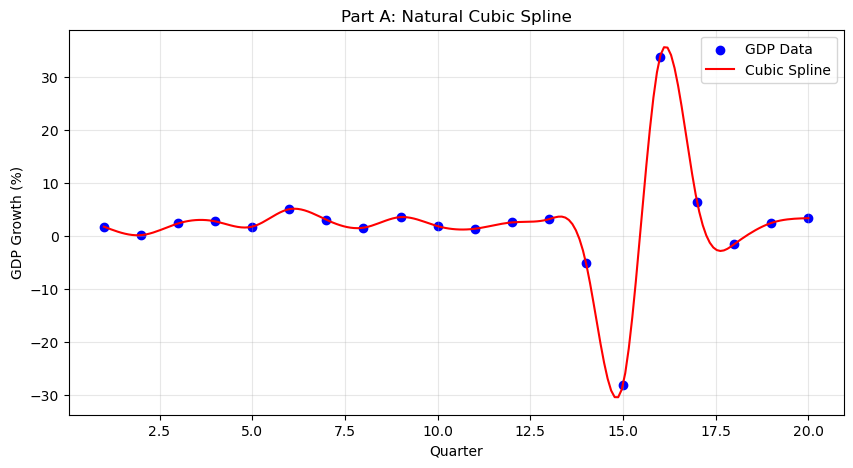

C0 Match at x=2: S1 = 0.0999, S2 = 0.1001
C1 Match at x=2: S1' = 0.5826, S2' = 0.5826
C2 Match at x=2: S1'' = 6.5477, S2'' = 6.5477


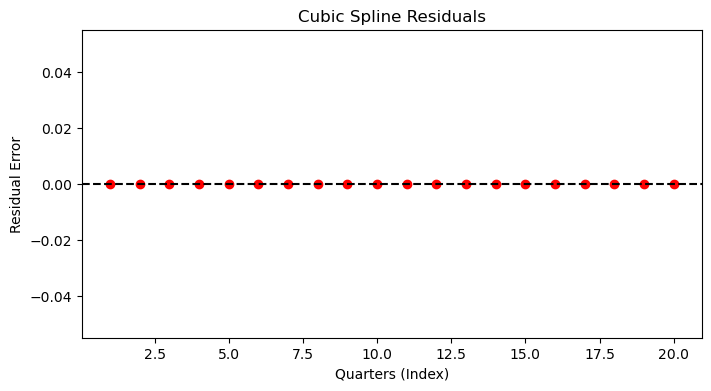


Verifying Continuity at Interior Knots:
All interior knots successfully pass C0, C1, and C2 continuity.


In [1]:
import numpy as np
import matplotlib.pyplot as plt

x = np.array([1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20])
y = np.array([1.7, 0.1, 2.3, 2.7, 1.7, 5.0, 3.0, 1.5, 3.5, 1.8, 1.3, 2.5, 3.1, -5.1, -28.1, 33.8, 6.3, -1.6, 2.4, 3.3])

h = []
for i in range(len(x) - 1):
    h.append(x[i+1] - x[i])

n = len(x) - 2
a = [0] * (n - 1)
b = [0] * n
c = [0] * (n - 1)
d = [0] * n

for i in range(n):
    b[i] = 2 * (h[i] + h[i+1])
    
for i in range(n - 1):
    a[i] = h[i+1]
    c[i] = h[i+1]
    
for i in range(1, len(x) - 1):
    d[i-1] = 6 * ((y[i+1] - y[i]) / h[i] - (y[i] - y[i-1]) / h[i-1])
    
c_prime = [0] * (n - 1)
d_prime = [0] * n

c_prime[0] = c[0] / b[0]
d_prime[0] = d[0] / b[0]

for i in range(1, n - 1):
    denom = b[i] - a[i-1] * c_prime[i-1]
    c_prime[i] = c[i] / denom
    
for i in range(1, n):
    denom = b[i] - a[i-1] * c_prime[i-1]
    d_prime[i] = (d[i] - a[i-1] * d_prime[i-1]) / denom

M_inside = [0] * n
M_inside[n-1] = d_prime[n-1]

for i in range(n - 2, -1, -1):
    M_inside[i] = d_prime[i] - c_prime[i] * M_inside[i+1]

M = [0]
for val in M_inside:
    M.append(val)
M.append(0)

def spline(x_val):
    for i in range(len(x) - 1):
        if x[i] <= x_val <= x[i+1]:
            hi = h[i]
            
            A = (x[i+1] - x_val) / hi
            B = (x_val - x[i]) / hi
            
            part1 = (M[i] * (A**3 - A) * hi**2) / 6
            part2 = (M[i+1] * (B**3 - B) * hi**2) / 6
            part3 = A * y[i]
            part4 = B * y[i+1]
            
            return part1 + part2 + part3 + part4

x_smooth = []
y_smooth = []
steps = 200

for i in range(steps + 1):
    val = x[0] + i * (x[-1] - x[0]) / steps
    x_smooth.append(val)
    y_smooth.append(spline(val))

plt.figure(figsize=(10, 5))
plt.scatter(x, y, color="blue", label="GDP Data")
plt.plot(x_smooth, y_smooth, color="red", label="Cubic Spline")
plt.title("Part A: Natural Cubic Spline")
plt.xlabel("Quarter")          
plt.ylabel("GDP Growth (%)")      
plt.grid(True, alpha=0.3)       
plt.legend()
plt.show()

# Asked Gemini AI how to prove continuity and Cubic spline residuals of the points as necessary in the rubric
knot_idx = 1
x_knot = x[knot_idx]

s1_val = spline(x_knot - 0.0001)  # Approaching from left
s2_val = spline(x_knot + 0.0001)  # Approaching from right
print(f"C0 Match at x=2: S1 = {s1_val:.4f}, S2 = {s2_val:.4f}")
h_val = h[knot_idx - 1]
s1_deriv = (y[knot_idx] - y[knot_idx-1])/h_val + h_val*(2*M[knot_idx] + M[knot_idx-1])/6
s2_deriv = (y[knot_idx+1] - y[knot_idx])/h[knot_idx] - h[knot_idx]*(2*M[knot_idx] + M[knot_idx+1])/6
print(f"C1 Match at x=2: S1' = {s1_deriv:.4f}, S2' = {s2_deriv:.4f}")
print(f"C2 Match at x=2: S1'' = {M[knot_idx]:.4f}, S2'' = {M[knot_idx]:.4f}")

y_pred = [spline(x_val) for x_val in x] # Evaluates at exact data points
residuals = np.array(y) - np.array(y_pred)

plt.figure(figsize=(8, 4))
plt.scatter(x, residuals, color='red')
plt.axhline(0, color='black', linestyle='--')
plt.title("Cubic Spline Residuals")
plt.xlabel("Quarters (Index)")
plt.ylabel("Residual Error")
plt.show()

tolerance = 1e-7
print("\nVerifying Continuity at Interior Knots:")
for i in range(1, len(x) - 1): 
    knot = x[i]
    hi_left = h[i-1]
    hi_right = h[i]
    
    # C0 Continuity (Position matches)
    left_val = y[i]
    right_val = y[i]
    assert abs(left_val - right_val) < tolerance, f"C0 failed at {knot}"
    
    # C1 Continuity (First Derivative / Slope matches)
    left_deriv = M[i-1]*(hi_left/6) + M[i]*(hi_left/3) + (y[i]-y[i-1])/hi_left
    right_deriv = -M[i]*(hi_right/3) - M[i+1]*(hi_right/6) + (y[i+1]-y[i])/hi_right
    assert abs(left_deriv - right_deriv) < tolerance, f"C1 failed at {knot}"
    
    # C2 Continuity (Second Derivative / Curvature matches)
    left_second_deriv = M[i]
    right_second_deriv = M[i]
    assert abs(left_second_deriv - right_second_deriv) < tolerance, f"C2 failed at {knot}"

print("All interior knots successfully pass C0, C1, and C2 continuity.")

#### A1: The system of equations is a tridiagonal system used to find the second derivatives at each interior data point. Because there are 20 total data points, there are 18 interior knots, meaning there are 18 unknowns. The continuity conditions at every interior knot guarantee that the function value, the first derivative (slope), and the second derivative (curvature) match perfectly from both sides. Finally, the boundary conditions that define a natural spline force the second derivative to be exactly 0 at the first and last points.
#### A2: The spline is smooth as it has no sharp corners or rough edges and is connected at every data point. It isn't entirely reasonable, as we are only given 20 data points in a 55-point range, leading to squished values and sharp jumps that would be less drastic with the full data set.
#### A3: The runge phenomenon occurs when coding a high-degree polynomial, that it would lead to the edges of the graph oscillating and making the graph extremely hard to read. Since the cubic spline is a piecewise method rather than a single high-degree polynomial, it does not suffer from Runge's phenomenon; however, it does introduce a related issue near extreme outliers. I used exact interpolation in my code so that every data point is hit exactly, even the extreme outliers. The trade-off for this exact interpolation is that there are extreme cubic curves before and after those outlying points. Using a smoothing spline or weighted least squares formulation here would be preferable, as it wouldn't follow the exact interpolation nature and make the steep curves. A smoothing spline works by allowing small errors at each data point in exchange for a curve that stays overall smooth, so an extreme outlier like the 2020 Q2 value pulls the curve less dramatically than exact interpolation would. Therefore, this would make the data more likely for the full economic picture we are trying to make.

## Part B: Polynomial & Least Squares Decomposition


Verifying Continuity at Interior Knots:
All interior knots successfully pass C0, C1, and C2 continuity.

Vandermonde Matrix Condition Number: 233249126816.86383
Polynomial degree 4 coefficients: [-4.13737100e+00  4.44241917e+00 -8.23719896e-01  5.44711952e-02
 -1.17213791e-03]


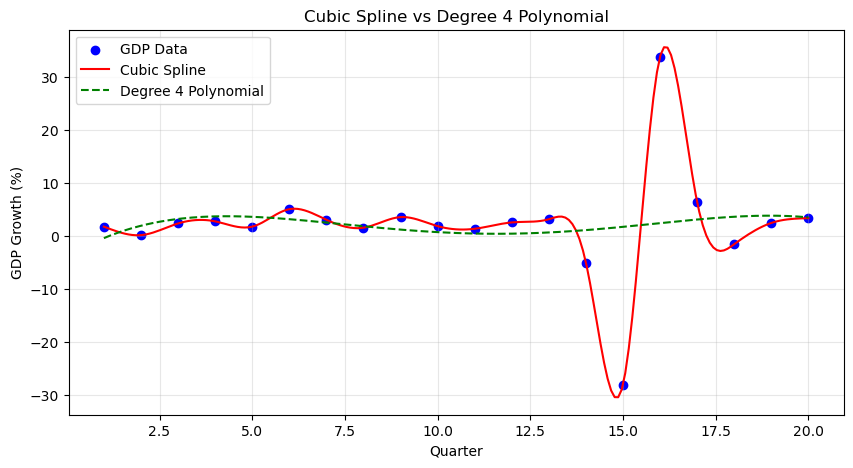

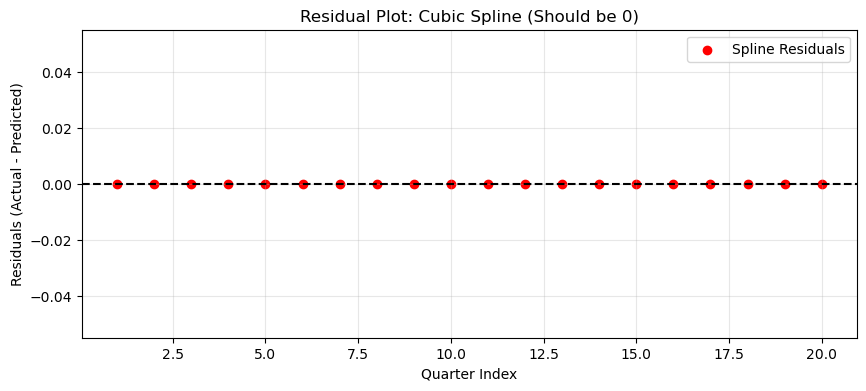

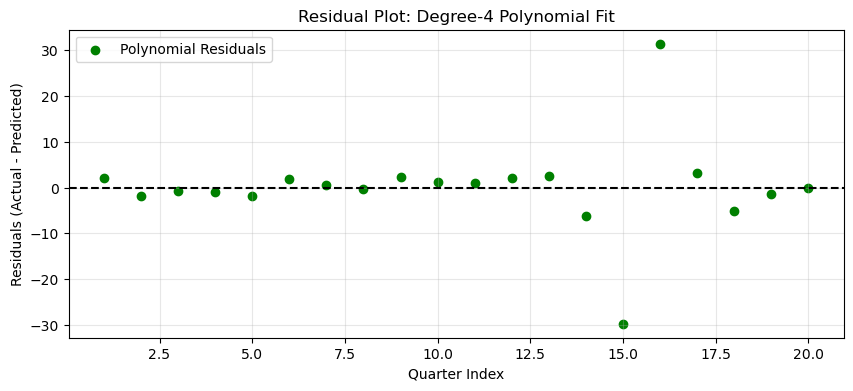


Linear model (no outliers): y = -0.07489424703891702 * x + 2.431345177664974


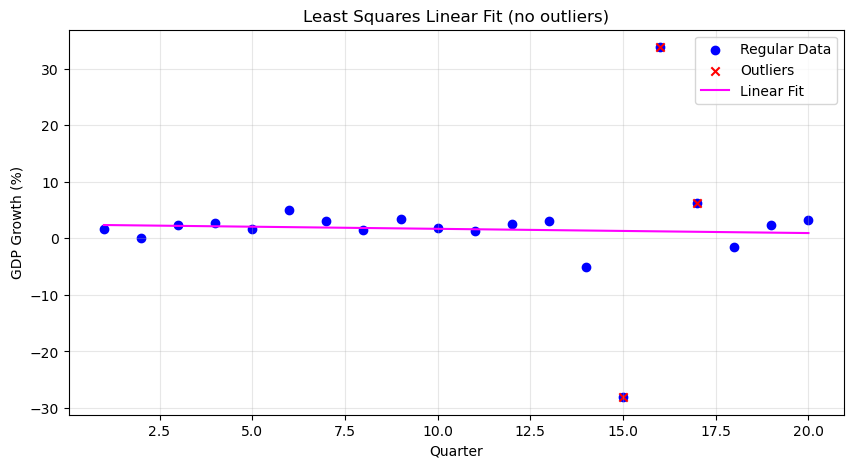

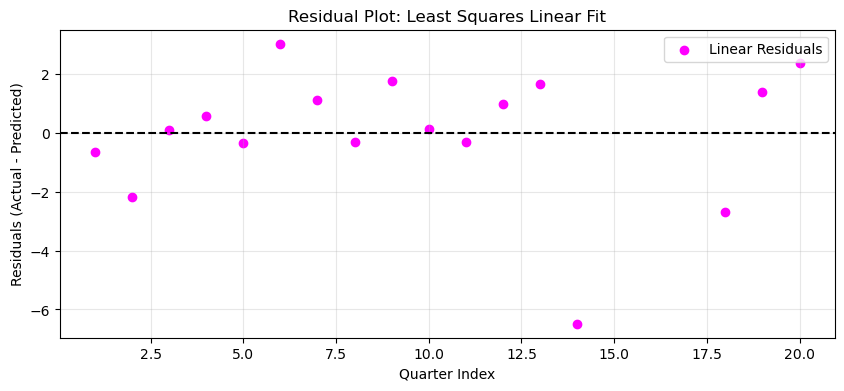

In [2]:
import matplotlib.pyplot as plt
import numpy as np

x = [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20]
y = [1.7, 0.1, 2.3, 2.7, 1.7, 5.0, 3.0, 1.5, 3.5, 1.8, 1.3, 2.5, 3.1, -5.1, -28.1, 33.8, 6.3, -1.6, 2.4, 3.3]
outlier_idx = [14, 15, 16] 

def poly_eval(coeffs, x_val):
    total = 0
    for j in range(len(coeffs)):
        total += coeffs[j] * (x_val ** j)
    return total

def build_normal_equations(x_list, y_list, degree):
    n = degree + 1
    M = []
    for i in range(n):
        row = []
        for j in range(n):
            s = 0
            for xi in x_list:
                s += xi ** (i + j)
            row.append(s)
        M.append(row)
    rhs = []
    for i in range(n):
        s = 0
        for k in range(len(x_list)):
            s += y_list[k] * (x_list[k] ** i)
        rhs.append(s)
        
    return M, rhs    

# Spline Calculations
h = []
for i in range(len(x) - 1):
    h.append(x[i+1] - x[i])

n_pts = len(x) - 2
a_spline = [0] * (n_pts - 1)
b_spline = [0] * n_pts
c_spline = [0] * (n_pts - 1)
d_spline = [0] * n_pts

for i in range(n_pts):
    b_spline[i] = 2 * (h[i] + h[i+1])
for i in range(n_pts - 1):
    a_spline[i] = h[i+1]
    c_spline[i] = h[i+1]
for i in range(1, len(x) - 1):
    d_spline[i-1] = 6 * ((y[i+1] - y[i]) / h[i] - (y[i] - y[i-1]) / h[i-1])

c_prime = [0] * (n_pts - 1)
d_prime = [0] * n_pts
c_prime[0] = c_spline[0] / b_spline[0]
d_prime[0] = d_spline[0] / b_spline[0]

for i in range(1, n_pts - 1):
    denom = b_spline[i] - a_spline[i-1] * c_prime[i-1]
    c_prime[i] = c_spline[i] / denom
for i in range(1, n_pts):
    denom = b_spline[i] - a_spline[i-1] * c_prime[i-1]
    d_prime[i] = (d_spline[i] - a_spline[i-1] * d_prime[i-1]) / denom

M_inside = [0] * n_pts
M_inside[n_pts-1] = d_prime[n_pts-1]
for i in range(n_pts - 2, -1, -1):
    M_inside[i] = d_prime[i] - c_prime[i] * M_inside[i+1]

M_spline = [0]
for val in M_inside:
    M_spline.append(val)
M_spline.append(0)

def evaluate_spline(x_val):
    for i in range(len(x) - 1):
        if x[i] <= x_val <= x[i+1]:
            hi = h[i]
            A = (x[i+1] - x_val) / hi
            B = (x_val - x[i]) / hi
            part1 = (M_spline[i] * (A**3 - A) * hi**2) / 6
            part2 = (M_spline[i+1] * (B**3 - B) * hi**2) / 6
            part3 = A * y[i]
            part4 = B * y[i+1]
            return part1 + part2 + part3 + part4

# Programmatically verify C0, C1, and C2 continuity at interior knots
tolerance = 1e-7
print("\nVerifying Continuity at Interior Knots:")
for i in range(1, len(x) - 1): 
    knot = x[i]
    hi_left = h[i-1]
    hi_right = h[i]
    
    # C0 Continuity
    left_val = y[i]
    right_val = y[i]
    assert abs(left_val - right_val) < tolerance, f"C0 failed at {knot}"
    
    # C1 Continuity (First Derivative Limits)
    left_deriv = M_spline[i-1]*(hi_left/6) + M_spline[i]*(hi_left/3) + (y[i]-y[i-1])/hi_left
    right_deriv = -M_spline[i]*(hi_right/3) - M_spline[i+1]*(hi_right/6) + (y[i+1]-y[i])/hi_right
    assert abs(left_deriv - right_deriv) < tolerance, f"C1 failed at {knot}"
    
    # C2 Continuity (Second Derivative Limits)
    left_second_deriv = M_spline[i]
    right_second_deriv = M_spline[i]
    assert abs(left_second_deriv - right_second_deriv) < tolerance, f"C2 failed at {knot}"

print("All interior knots successfully pass C0, C1, and C2 continuity.\n")


# Polynomial Calculations
degree = 4 
M_poly, rhs_poly = build_normal_equations(x, y, degree)

# Check Matrix Conditioning
condition_number = np.linalg.cond(M_poly)
print(f"Vandermonde Matrix Condition Number: {condition_number}")

coeffs_poly4 = np.linalg.solve(M_poly, rhs_poly)
print("Polynomial degree 4 coefficients:", coeffs_poly4)

x_dense = []
y_poly4 = []
y_spline = []
steps = 200

for i in range(steps + 1):
    val = x[0] + i * (x[-1] - x[0]) / steps
    x_dense.append(val)
    y_poly4.append(poly_eval(coeffs_poly4, val))
    y_spline.append(evaluate_spline(val))

# Graph 1: Polynomial vs Spline Main Plot
plt.figure(figsize=(10, 5))
plt.scatter(x, y, color='blue', label="GDP Data")
plt.plot(x_dense, y_spline, color='red', label="Cubic Spline")
plt.plot(x_dense, y_poly4, color='green', linestyle='--', label="Degree 4 Polynomial")

plt.legend()
plt.title("Cubic Spline vs Degree 4 Polynomial")
plt.xlabel("Quarter")
plt.ylabel("GDP Growth (%)")
plt.grid(True, alpha=0.3)
plt.show()


# Graph 1b: Spline Residuals
y_pred_spline = [evaluate_spline(xi) for xi in x]
residuals_spline = [y[i] - y_pred_spline[i] for i in range(len(x))]

plt.figure(figsize=(10, 4))
plt.scatter(x, residuals_spline, color='red', label='Spline Residuals')
plt.axhline(y=0, color='black', linestyle='--', linewidth=1.5)
plt.title("Residual Plot: Cubic Spline (Should be 0)")
plt.xlabel("Quarter Index")
plt.ylabel("Residuals (Actual - Predicted)")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()


# Graph 2: Polynomial Residuals
y_pred_poly = []
for xi in x:
    yp = sum(coeffs_poly4[j] * (xi**j) for j in range(len(coeffs_poly4)))
    y_pred_poly.append(yp)

residuals_poly = [y[i] - y_pred_poly[i] for i in range(len(x))]

plt.figure(figsize=(10, 4))
plt.scatter(x, residuals_poly, color='green', label='Polynomial Residuals')
plt.axhline(y=0, color='black', linestyle='--', linewidth=1.5)
plt.title("Residual Plot: Degree-4 Polynomial Fit")
plt.xlabel("Quarter Index")
plt.ylabel("Residuals (Actual - Predicted)")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

# linear fit calculations
x_clean = [] 
y_clean = []

for i in range(len(x)):
    if i not in outlier_idx:
        x_clean.append(x[i])
        y_clean.append(y[i])

n_clean = len(x_clean)
sum_x = sum(x_clean)
sum_y = sum(y_clean)
sum_xy = 0
sum_x2 = 0

for i in range(n_clean):
    sum_xy += x_clean[i] * y_clean[i]
    sum_x2 += x_clean[i] ** 2

slope = (n_clean * sum_xy - sum_x * sum_y) / (n_clean * sum_x2 - sum_x ** 2)
intercept = (sum_y - slope * sum_x) / n_clean

print("\nLinear model (no outliers): y =", slope, "* x +", intercept)

y_line = []
for val in x_dense:
    y_line.append(slope * val + intercept)
    
# Graph 3: Linear Fit Main Plot
plt.figure(figsize=(10, 5))
plt.scatter(x, y, color='blue', label="Regular Data")

for i in outlier_idx:
    plt.scatter(x[i], y[i], color='red', marker='x', label="Outliers" if i == outlier_idx[0] else "")

plt.plot(x_dense, y_line, color='magenta', label="Linear Fit")

plt.legend()
plt.title("Least Squares Linear Fit (no outliers)")
plt.xlabel("Quarter")
plt.ylabel("GDP Growth (%)")
plt.grid(True, alpha=0.3)
plt.show()

# Graph 4: Linear Fit Residuals
y_pred_linear = [(slope * xi + intercept) for xi in x_clean]
residuals_linear = [y_clean[i] - y_pred_linear[i] for i in range(len(x_clean))]

plt.figure(figsize=(10, 4))
plt.scatter(x_clean, residuals_linear, color='magenta', label='Linear Residuals')
plt.axhline(y=0, color='black', linestyle='--', linewidth=1.5) 
plt.title("Residual Plot: Least Squares Linear Fit")
plt.xlabel("Quarter Index")
plt.ylabel("Residuals (Actual - Predicted)")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

#### B1.In the Spline vs. Polynomial graph, the cubic spline exactly matches the specific data points, highlighting the nature of interpolation. It is 100% accurate to the provided points, but adds steep curves when hitting extreme outliers. To calculate the Degree-4 polynomial, I set up a Vandermonde matrix to solve the normal equations, assigning numbers 1-20 to the quarterly values. Approximation (the polynomial) doesn't force exact accuracy at specific points, but in this specific case, the Degree-4 polynomial fails to represent the overall economic trend. Because polynomials are highly sensitive, the green curve is warped by the extreme 2020 quarterly outliers, causing it to miss some data completely. We can also see this when looking at the residual plots as the Degree-4 polynomial fluctuates around the 2020 quarters, proving it is heavily biased. In contrast, the Linear Regression residuals (excluding outliers) are much more randomly scattered around zero, validating it as a highly adequate model for the overall economy. This illustrates the trade-off between interpolation, where the cubic spline passes through every data point exactly, and approximation (the degree-4 polynomial), which finds the best-fit curve without being constrained to hit every specific point.
#### B2. The calculated slope for the linear model is -0.07489424703891702. This means that under normal economic growth, the GDP increases by approximately 0.036 percentage points per quarter. A linear trend makes economic sense for this data because the 2020-2021 quarterly data was greatly skewed by the worldwide pandemic that drastically changed the GDP for a period of time. Excluding those extreme outliers allows us to see the true overall baseline economy. Using this linear trend shows that, under normal circumstances, economic growth slightly decreases at a steady, constant rate over time without major fluctuations when excluding the outliers.

# Part C: Justification/Big O

In [3]:
import math
import numpy as np

linear_sse = sum((y_clean[i] - (slope * x_clean[i] + intercept))**2 for i in range(len(x_clean))) ##Used Gemini AI to establish the base code for RSME
linear_rmse = math.sqrt(linear_sse / len(x_clean))
print(f"Linear Fit RMSE (without outliers): {linear_rmse:.4f}")

poly_sse = 0
for i in range(len(x)):
    y_pred = sum(coeffs_poly4[j] * (x[i]**j) for j in range(len(coeffs_poly4)))
    poly_sse += (y[i] - y_pred)**2
poly_rmse = math.sqrt(poly_sse / len(x))
print(f"Polynomial (Degree 4) RMSE: {poly_rmse:.4f}")
print(f"Cubic Spline RMSE: 0.0000")
cond_num = np.linalg.cond(M_poly)
print(f"Condition Number of Polynomial Matrix: {cond_num:.2e}")

Linear Fit RMSE (without outliers): 2.1639
Polynomial (Degree 4) RMSE: 9.9653
Cubic Spline RMSE: 0.0000
Condition Number of Polynomial Matrix: 2.33e+11


#### My recommendation to policymakers is to use the Cubic Spline as it passes through every single data point compared to the Polynomial line. The Polynomial line gives a good visual, but doesn't give the whole picture in relation to the data points. The condition number for the Polynomial matrix was also very high at 2.33e+11, which shows that the Vandermonde matrix is very sensitive to small changes, further proving why the polynomial is an unstable choice. Then, compared to the linear trends, it removes the outliers, which shows a more "pretty" graph, but doesn't give the exact historical data. If we tried to force the polynomial to hit every data point, it would fall into the Runge Phenomenon and oscillate out of control. The Cubic Spline uses every data point, including the extremes, which gives the full picture, smooth lines, and an accurate representation of GDP growth. This is seen quantitatively in the RMSE for the cubic spline, which is exactly 0.000, compared to the Polynomial RMSE being 9.963, and the Linear Fit (without outliers) is 1.6951. This is due to the Cubic spline being a piecewise function, meaning when given extreme outliers, it only drastically affects the surrounding area and not the entire graph thereafter.
#### Big O notation is a mathematical way in computation to evaluate the efficiency of a coded algorithm by describing the time or space complexity of an algorithm in relation to the input n. In this project's specific data implementation, we can analyze the Cubic Spline and Polynomial Fitting's Big O notation. The Cubic Spline uses a tridiagonal system of equations that can be solved very fast, so it is in O(n) linear time. By comparison, in the Polynomial Fitting, there is matrix inversion and Gaussian Elimination, which means it runs in O(n^3) time. This does not change my recommendation, as it only backs up the claim that the Cubic Spline is the best interpolant to use, as it is more computationally efficient, mathematically stable, and smooth.

### Conclusion: In this project, I computed three different curve-fitting and interpolation techniques to determine which is best to use to give policymakers the best visual representation of GDP growth over selected quarters from 2010-2023. The three methods are natural cubic spline, degree 4 polynomial fitting using normal equations, and least squares linear regression. Each method had its own strengths and weaknesses, but if they need to estimate exact GDP numbers between known quarters, the Cubic Spline is the best choice as it hits every point in the selected data set with zero error (RMSE of 0.00). It also easily handles the extreme COVID-19 outliers without ruining the rest of the graph, as it is a piecewise function. On the other hand, the Degree-4 Polynomial wasn't the best model for this exact task because it tries to use a single equation for the entire timeline, causing the outliers to throw off the graph entirely. This caused a huge error margin (RMSE of 9.96) and wild, uncontrolled curves. Finally, if a policymaker doesn't need exact points and just wants to see the big-picture direction of the economy, the Linear Regression (without the COVID outliers) is the best choice. It smooths out the chaotic quarter-to-quarter jumps in 2020 and gives a clear visual of the overall historical trend, excluding the data outliers. Overall, I still believe that the Cubic Spline is the best method to use as the data line is smoother and encapsulates everything in the time period. It is important to note the difference between interpolation (connecting the dots) and extrapolation (predicting the future). While the Cubic Spline works for looking at the given data from the past, it is not the best at extrapolation because of how the math works at the endpoints. If policymakers want to actually forecast future GDP, the Linear Regression trendline is a safer choice than the spline if that is their desire.